In [ ]:
import os
print(os.listdir("/content"))

['.config', 'drive', 'outputs', 'road_accident_risk_india.csv', 'sample_data']


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/road_accident_risk_india_noise0.4.csv", keep_default_na=False)
print(df.shape)
df.head()

(5000, 22)


,State Name,City Name,Year,Month,Day of Week,Time of Day,Accident Severity,Number of Vehicles Involved,Vehicle Type Involved,Number of Casualties,...,Road Type,Road Condition,Lighting Conditions,Traffic Control Presence,Speed Limit (km/h),Driver Age,Driver License Status,Alcohol Involvement,Accident Location Details,High Risk
0,Bihar,Gaya,2021,November,Tuesday,08:06,Minor,3,Two-Wheeler,3,...,Urban Road,Dry,Daylight,Signs,40,39,Unlicensed,No,Intersection,0
1,Gujarat,Surat,2019,November,Thursday,09:21,Minor,2,Car,1,...,Urban Road,Dry,Daylight,Signs,45,41,Valid,No,Straight Road,0
2,Delhi,New Delhi,2019,December,Saturday,21:18,Serious,1,Two-Wheeler,3,...,State Highway,Dry,Dark,Signs,80,46,Valid,No,Straight Road,1
3,Andhra Pradesh,Vijayawada,2020,January,Friday,18:40,Fatal,1,Two-Wheeler,3,...,National Highway,Damaged,Dusk,Signals,85,57,Expired,No,Straight Road,1
4,Maharashtra,Pune,2018,November,Monday,06:20,Serious,5,Truck,3,...,National Highway,Dry,Daylight,Signs,90,39,Valid,No,Curve,1


In [ ]:
print(df.isnull().sum())
print(df["High Risk"].value_counts())

State Name                     0
City Name                      0
Year                           0
Month                          0
Day of Week                    0
Time of Day                    0
Accident Severity              0
Number of Vehicles Involved    0
Vehicle Type Involved          0
Number of Casualties           0
Number of Fatalities           0
Weather Conditions             0
Road Type                      0
Road Condition                 0
Lighting Conditions            0
Traffic Control Presence       0
Speed Limit (km/h)             0
Driver Age                     0
Driver License Status          0
Alcohol Involvement            0
Accident Location Details      0
High Risk                      0
dtype: int64
High Risk
1    2750
0    2250
Name: count, dtype: int64


In [ ]:
df["Hour"] = df["Time of Day"].str[:2].astype(int)

df = df.drop(columns=["Accident Severity", "Number of Casualties", "Number of Fatalities",
                      "City Name", "State Name", "Time of Day"])

X = df.drop(columns=["High Risk"])   # X = inputs (what the model looks at)
y = df["High Risk"]                  # y = target (what we predict)

In [ ]:
X = pd.get_dummies(X, drop_first=True)
print(X.shape)

(5000, 51)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape, X_test.shape)

(4000, 51) (1000, 51)


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
print("Logistic Regression accuracy:", round(accuracy_score(y_test, lr_pred), 3))

Logistic Regression accuracy: 0.836


In [ ]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("Random Forest accuracy:", round(accuracy_score(y_test, rf_pred), 3))

Random Forest accuracy: 0.809


              precision    recall  f1-score   support

           0       0.84      0.78      0.81       450
           1       0.83      0.88      0.86       550

    accuracy                           0.84      1000
   macro avg       0.84      0.83      0.83      1000
weighted avg       0.84      0.84      0.84      1000



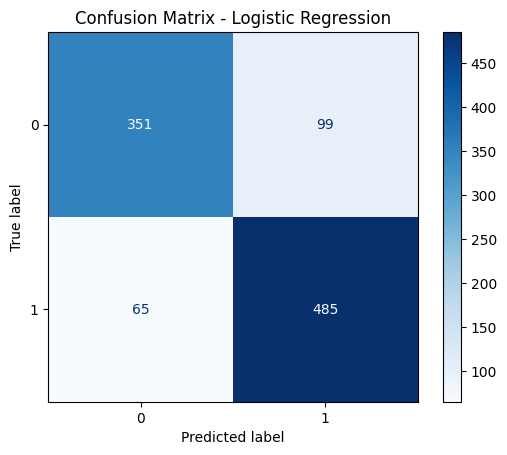

In [ ]:
print(classification_report(y_test, lr_pred))
ConfusionMatrixDisplay(confusion_matrix(y_test, lr_pred)).plot(cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

Speed Limit (km/h)             0.179436
Driver Age                     0.069175
Hour                           0.064197
Road Type_Urban Road           0.059003
Number of Vehicles Involved    0.045335
Year                           0.044412
Road Type_National Highway     0.038846
Alcohol Involvement_Yes        0.038482
Road Condition_Dry             0.030749
Road Type_Village Road         0.026218
dtype: float64


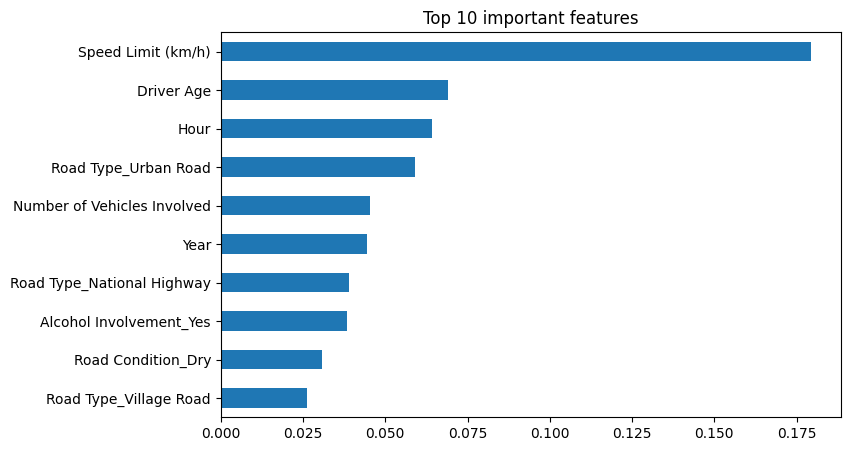

In [ ]:
importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importance.head(10))

importance.head(10).sort_values().plot(kind="barh", figsize=(8, 5), title="Top 10 important features")
plt.show()

In [ ]:
results = pd.DataFrame({"Actual": y_test.values[:10], "Predicted": lr_pred[:10]})
results

,Actual,Predicted
0,1,1
1,0,1
2,1,0
3,0,0
4,0,0
5,0,1
6,0,1
7,1,1
8,1,1
9,1,1


In [ ]:
def predict_risk(accident):
    new_df = pd.DataFrame([accident])                          # put the inputs in a table
    new_df = pd.get_dummies(new_df)                            # turn text into 0/1 columns
    new_df = new_df.reindex(columns=X.columns, fill_value=0)   # match the training columns
    scaled = scaler.transform(new_df)                          # scale like the training data
    pred = lr.predict(scaled)[0]
    prob = lr.predict_proba(scaled)[0][1]
    print("Prediction:", "HIGH RISK (Serious/Fatal)" if pred == 1 else "LOW RISK (Minor)")
    print("Probability of high risk:", round(prob * 100, 1), "%")

my_accident = {
    "Year": 2024, "Month": "December", "Day of Week": "Saturday",
    "Number of Vehicles Involved": 3, "Vehicle Type Involved": "Two-Wheeler",
    "Weather Conditions": "Foggy", "Road Type": "National Highway",
    "Road Condition": "Wet", "Lighting Conditions": "Dark",
    "Traffic Control Presence": "No Control", "Speed Limit (km/h)": 90,
    "Driver Age": 22, "Driver License Status": "Unlicensed",
    "Alcohol Involvement": "Yes", "Accident Location Details": "Curve", "Hour": 23
}
predict_risk(my_accident)

Prediction: HIGH RISK (Serious/Fatal)
Probability of high risk: 100.0 %


In [ ]:
!pip install -q scikit-learn pandas joblib fastapi uvicorn pydantic

In [ ]:
import joblib, json
from pathlib import Path

MODEL_DIR = Path("model_v1")
MODEL_DIR.mkdir(exist_ok=True)

joblib.dump(lr, MODEL_DIR / "student_model.pkl")
joblib.dump(scaler, MODEL_DIR / "scaler.pkl")
joblib.dump(list(X.columns), MODEL_DIR / "columns.pkl")

model_info = {
    "model_version": "V1",
    "training_rows": len(df),
    "test_accuracy": round(accuracy_score(y_test, lr_pred), 4),
    "features_raw": [
        "Year", "Month", "Day of Week", "Number of Vehicles Involved",
        "Vehicle Type Involved", "Weather Conditions", "Road Type",
        "Road Condition", "Lighting Conditions", "Traffic Control Presence",
        "Speed Limit (km/h)", "Driver Age", "Driver License Status",
        "Alcohol Involvement", "Accident Location Details", "Hour"
    ]
}
(MODEL_DIR / "model_info.json").write_text(json.dumps(model_info, indent=2))
print(model_info)

{'model_version': 'V1', 'training_rows': 5000, 'test_accuracy': 0.836, 'features_raw': ['Year', 'Month', 'Day of Week', 'Number of Vehicles Involved', 'Vehicle Type Involved', 'Weather Conditions', 'Road Type', 'Road Condition', 'Lighting Conditions', 'Traffic Control Presence', 'Speed Limit (km/h)', 'Driver Age', 'Driver License Status', 'Alcohol Involvement', 'Accident Location Details', 'Hour']}


In [ ]:
%%writefile app.py
from fastapi import FastAPI
from pydantic import BaseModel
import joblib, json
import pandas as pd
from pathlib import Path

app = FastAPI(title="Road Accident Risk Prediction API")

BASE_DIR = Path(__file__).parent
lr = joblib.load(BASE_DIR / "student_model.pkl")
scaler = joblib.load(BASE_DIR / "scaler.pkl")
columns = joblib.load(BASE_DIR / "columns.pkl")
model_info = json.loads((BASE_DIR / "model_info.json").read_text())

class AccidentInput(BaseModel):
    Year: int
    Month: str
    Day_of_Week: str
    Number_of_Vehicles_Involved: int
    Vehicle_Type_Involved: str
    Weather_Conditions: str
    Road_Type: str
    Road_Condition: str
    Lighting_Conditions: str
    Traffic_Control_Presence: str
    Speed_Limit_kmh: int
    Driver_Age: int
    Driver_License_Status: str
    Alcohol_Involvement: str
    Accident_Location_Details: str
    Hour: int

@app.get("/")
def root():
    return {"status": "ok", "model_info": model_info}

@app.post("/predict")
def predict(accident: AccidentInput):
    raw = {
        "Year": accident.Year, "Month": accident.Month,
        "Day of Week": accident.Day_of_Week,
        "Number of Vehicles Involved": accident.Number_of_Vehicles_Involved,
        "Vehicle Type Involved": accident.Vehicle_Type_Involved,
        "Weather Conditions": accident.Weather_Conditions,
        "Road Type": accident.Road_Type,
        "Road Condition": accident.Road_Condition,
        "Lighting Conditions": accident.Lighting_Conditions,
        "Traffic Control Presence": accident.Traffic_Control_Presence,
        "Speed Limit (km/h)": accident.Speed_Limit_kmh,
        "Driver Age": accident.Driver_Age,
        "Driver License Status": accident.Driver_License_Status,
        "Alcohol Involvement": accident.Alcohol_Involvement,
        "Accident Location Details": accident.Accident_Location_Details,
        "Hour": accident.Hour,
    }
    # IMPORTANT: must use drop_first=True to match training
    new_df = pd.DataFrame([raw])
    new_df = pd.get_dummies(new_df, drop_first=True)
    new_df = new_df.reindex(columns=columns, fill_value=0)
    scaled = scaler.transform(new_df)

    pred = lr.predict(scaled)[0]
    prob = lr.predict_proba(scaled)[0][1]
    return {
        "prediction": "HIGH RISK (Serious/Fatal)" if pred == 1 else "LOW RISK (Minor)",
        "probability_high_risk_percent": round(float(prob) * 100, 1)
    }

Writing app.py


In [ ]:
import shutil, sklearn
from pathlib import Path

DEPLOY_DIR = Path("student-mlops-api")
DEPLOY_DIR.mkdir(exist_ok=True)

for fname in ["student_model.pkl", "scaler.pkl", "columns.pkl", "model_info.json"]:
    shutil.copy(MODEL_DIR / fname, DEPLOY_DIR / fname)
shutil.copy("app.py", DEPLOY_DIR / "app.py")

(DEPLOY_DIR / "requirements.txt").write_text(
    "fastapi\nuvicorn\npydantic\n"
    f"scikit-learn=={sklearn.__version__}\n"
    "joblib\npandas\n"
)

(DEPLOY_DIR / "render.yaml").write_text(
"""services:
  - type: web
    name: road-accident-risk-api
    env: python
    buildCommand: pip install -r requirements.txt
    startCommand: uvicorn app:app --host 0.0.0.0 --port $PORT
"""
)

print("Deploy folder ready:")
for item in sorted(DEPLOY_DIR.iterdir()):
    print(item.name, item.stat().st_size, "bytes")

Deploy folder ready:
app.py 2376 bytes
columns.pkl 1274 bytes
model_info.json 479 bytes
render.yaml 185 bytes
requirements.txt 59 bytes
scaler.pkl 3327 bytes
student_model.pkl 1279 bytes


In [ ]:
import shutil
shutil.make_archive('risk-mlops-api', 'zip', 'risk-mlops-api')

from google.colab import files
files.download('risk-mlops-api.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>